<a href="https://colab.research.google.com/github/rich7420/CNN-Assignment-2025/blob/main/CNN_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
%pip install tensorflow

  Using cached wheel-0.45.1-py3-none-any.whl.metadata (2.3 kB)
   ---------------------------------------- 0.0/375.7 MB ? eta -:--:--
   ---------------------------------------- 1.8/375.7 MB 14.3 MB/s eta 0:00:27
    --------------------------------------- 5.8/375.7 MB 16.8 MB/s eta 0:00:23
   - -------------------------------------- 12.3/375.7 MB 22.7 MB/s eta 0:00:17
   - -------------------------------------- 17.8/375.7 MB 23.4 MB/s eta 0:00:16
   -- ------------------------------------- 23.3/375.7 MB 23.8 MB/s eta 0:00:15
   --- ------------------------------------ 28.6/375.7 MB 24.2 MB/s eta 0:00:15
   --- ------------------------------------ 32.8/375.7 MB 23.6 MB/s eta 0:00:15
   ---- ----------------------------------- 38.3/375.7 MB 23.8 MB/s eta 0:00:15
   ---- ----------------------------------- 44.0/375.7 MB 24.4 MB/s eta 0:00:14
   ----- ---------------------------------- 50.1/375.7 MB 24.7 MB/s eta 0:00:14
   ----- ---------------------------------- 55.6/375.7 MB 24.7 MB/s 


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
%pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.2.3-py3-none-any.whl.metadata (5.0 kB)
   ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
   -------- ------------------------------- 1.6/7.8 MB 16.8 MB/s eta 0:00:01
   ---------------------------------------- 7.8/7.8 MB 22.0 MB/s eta 0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 26.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 2.7/2.7 MB 31.0 MB/s eta 0:00:00
Using cached pyparsing-3.2.3-py3-none-any.whl (111 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# CNN Classroom Exercise: Image Classification with CIFAR-10
# Objective: Practice building, training, and evaluating a CNN using TensorFlow/Keras
# Environment: Google Colab with GPU
# Dataset: CIFAR-10 (10 classes of 32x32 color images)

# Step 1: Import Libraries
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

In [6]:
# Step 2: Load and Preprocess CIFAR-10 Dataset
# CIFAR-10 contains 60,000 32x32 color images in 10 classes (e.g., airplane, cat, dog)
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalize pixel values to range [0, 1]
train_images, test_images = train_images / 255.0, test_images / 255.0

# Define class names for visualization
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 35s 0us/step


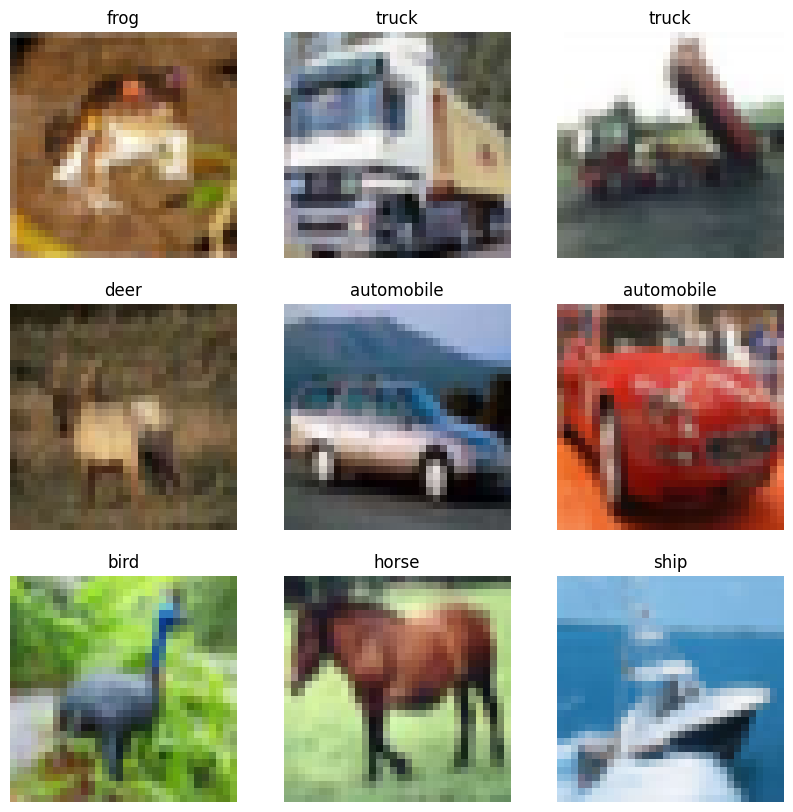

In [7]:
# Step 3: Visualize Sample Data
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(train_images[i])
    plt.title(class_names[train_labels[i][0]])
    plt.axis('off')
plt.show()

In [ ]:
# Task 3: Data Augmentation

from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rotation_range=7.5,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
train_generator = train_datagen.flow(train_images, train_labels, batch_size=64)

In [ ]:
#Task 1: Model Architecture Enhancement

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# 根據最佳超參數組合建立模型
model = models.Sequential()

# 第一層卷積：64 filters, 3x3 kernel (改為較小的kernel)
model.add(layers.Conv2D(64, (3, 3), padding='same', input_shape=(32, 32, 3)))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.2))  # dropout1 = 0.2

# 第二層卷積：64 filters, 3x3 kernel
model.add(layers.Conv2D(64, (3, 3), padding='same'))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.1))  # dropout1 = 0.1

# 第三層卷積：128 filters
model.add(layers.Conv2D(128, (3, 3), padding='same'))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.Dropout(0.3))  # dropout2 = 0.3

# 第四層卷積：128 filters
model.add(layers.Conv2D(128, (3, 3), padding='same'))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.3))  # dropout2 = 0.3

# 第五層卷積：新增
model.add(layers.Conv2D(128, (3, 3), padding='same'))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.Dropout(0.3))

# 平坦化並輸出至全連接層
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))  # 新增 Dense 層
model.add(layers.Dropout(0.3))
model.add(layers.Dense(64, activation='relu'))  # 原 Dense 層
model.add(layers.Dropout(0.3))  # dropout_dense = 0.3
model.add(layers.Dense(10, activation='softmax'))

# Task 2: Hyperparameter Optimization

#編譯模型
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),  # best lr
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 顯示模型架構
model.summary()

# 設定回呼函數：EarlyStopping + ReduceLROnPlateau
callbacks_list = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
]

# 記錄所有訓練歷程（可多次訓練後合併）
histories = []

# 訓練模型
temp_history = model.fit(
    train_generator,
    epochs=30,
    validation_data=(test_images, test_labels),
    callbacks=callbacks_list
)

histories.append(temp_history)

c:\Users\et611\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 680,970 (2.60 MB)

 Trainable params: 679,946 (2.59 MB)

 Non-trainable params: 1,024 (4.00 KB)

Epoch 1/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 46ms/step - accuracy: 0.2593 - loss: 1.9915 - val_accuracy: 0.4285 - val_loss: 1.6344 - learning_rate: 0.0010
Epoch 2/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 37s 47ms/step - accuracy: 0.4604 - loss: 1.4885 - val_accuracy: 0.4911 - val_loss: 1.3770 - learning_rate: 0.0010
Epoch 3/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step - accuracy: 0.5332 - loss: 1.3135 - val_accuracy: 0.4120 - val_loss: 1.9291 - learning_rate: 0.0010
Epoch 4/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 45s 58ms/step - accuracy: 0.5845 - loss: 1.1935 - val_accuracy: 0.5682 - val_loss: 1.2373 - learning_rate: 0.0010
Epoch 5/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 46s 59ms/step - accuracy: 0.6140 - loss: 1.1134 - val_accuracy: 0.5238 - val_loss: 1.4719 - learning_rate: 0.0010
Epoch 6/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 44s 57ms/step - accuracy: 0.6422 - loss: 1.0419 - val_accuracy: 0.6036 - val_loss: 1.1139 - learning_rate: 0.0010
Epoch 7/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 45s 57ms/step - accuracy: 0.6639 - l

In [13]:
# Step 7: Evaluate the Model
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f"\nTest accuracy: {test_acc:.4f}")


313/313 - 2s - 6ms/step - accuracy: 0.8157 - loss: 0.5371

Test accuracy: 0.8157


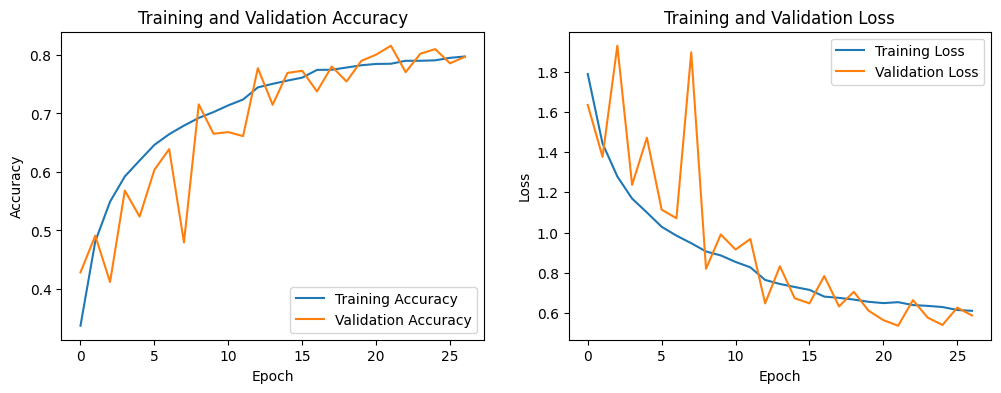

In [ ]:
#Task 4: Visualization

# Step 8: Plot Training and Validation Accuracy from multiple histories
plt.figure(figsize=(12, 4))

# 建立記錄用的空 list
train_acc_all, val_acc_all, train_loss_all, val_loss_all = [], [], [], []

# 合併多段訓練結果
for h in histories:
    train_acc_all.extend(h.history['accuracy'])
    val_acc_all.extend(h.history['val_accuracy'])
    train_loss_all.extend(h.history['loss'])
    val_loss_all.extend(h.history['val_loss'])

# 畫出 Accuracy 曲線
plt.subplot(1, 2, 1)
plt.plot(train_acc_all, label='Training Accuracy')
plt.plot(val_acc_all, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# 畫出 Loss 曲線
plt.subplot(1, 2, 2)
plt.plot(train_loss_all, label='Training Loss')
plt.plot(val_loss_all, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


In [19]:
# Step 9: Make Predictions
predictions = model.predict(test_images[:5])
for i in range(5):
    predicted_label = class_names[np.argmax(predictions[i])]
    true_label = class_names[test_labels[i][0]]
    print(f"Image {i+1}: Predicted: {predicted_label}, True: {true_label}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
Image 1: Predicted: cat, True: cat
Image 2: Predicted: ship, True: ship
Image 3: Predicted: ship, True: ship
Image 4: Predicted: airplane, True: airplane
Image 5: Predicted: frog, True: frog


In [22]:
# Step 10: Save Model Performance for Autograding
# This cell saves the model performance to a text file for GitHub Actions
try:
    history = histories[-1]
    # Get final training accuracy
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]
    final_train_loss = history.history['loss'][-1]
    final_val_loss = history.history['val_loss'][-1]

    # Create performance summary
    performance_text = f"""Model Performance Summary:
Test Accuracy: {test_acc:.4f}
Test Loss: {test_loss:.4f}
Final Training Accuracy: {final_train_acc:.4f}
Final Validation Accuracy: {final_val_acc:.4f}
Final Training Loss: {final_train_loss:.4f}
Final Validation Loss: {final_val_loss:.4f}
Training Epochs: {len(history.history['accuracy'])}
Model Parameters: {model.count_params()}"""

    # Save to file for GitHub Actions
    with open('model_accuracy.txt', 'w') as f:
        f.write(performance_text)

    print("Model performance saved to model_accuracy.txt")
    print(performance_text)

except Exception as e:
    print(f"Error saving model performance: {e}")
    # Create a basic file even if there's an error
    with open('model_accuracy.txt', 'w') as f:
        f.write(f"Model execution completed with errors: {e}")

Model performance saved to model_accuracy.txt
Model Performance Summary:
Test Accuracy: 0.8157
Test Loss: 0.5371
Final Training Accuracy: 0.7973
Final Validation Accuracy: 0.7967
Final Training Loss: 0.6112
Final Validation Loss: 0.5880
Training Epochs: 27
Model Parameters: 680970


# Task 5: Report Section
## 1.資料增強
- 增加訓練資料多樣性，降低過擬合。
    - 旋轉
    - 左右平移
    - 翻轉
## 2.更改模型架構
- 使用3*3的filter，提取更細緻的特徵
- 加入 Batch Normalization，穩定訓練效果
- 使用ReLU
- 使用Dropout
- 五層捲積層
## 3.超參數最佳化
- 選擇優化器`Adam`
## 4.訓練監控與早停
- EarlyStopping：若驗證集損失連續 5 個 epoch 沒改善，停止訓練，防止過擬合。**在實際訓練中的第27Epoch觸發**
- ReduceLROnPlateau：當驗證損失停止改善時，自動降低學習率，加強局部最優收斂。**在訓練中觸發3次**
## 5. 模型訓練與歷程保存
- 記錄訓練與驗證準確率、損失，後續可視覺化或合併不同訓練階段。但好像沒有用到。